# PCA through Singular Value Decomposition

In [2]:
import numpy as np
# Defined 3 points in 2D-space:
X=np.array([[2, 1, 0],[4, 3, 0]])

# Calculate the covariance matrix:
mu = X.mean(axis=1, keepdims=True)   # mean (2x1)
Xc = X - mu                           # centered data
R = (Xc @ Xc.T) / Xc.shape[1]         # covariance (2x2)

# Calculate the SVD decomposition and new basis vectors:
[U,D,V]=np.linalg.svd(R)  # call SVD decomposition
u1=U[:,0] # new basis vectors
u2=U[:,1]

# Calculate the coordinates in new orthonormal basis:
Xi = U.T @ Xc

# Calculate the approximation of the original from new basis
#print(Xi1[:,None]) # add second dimention to array and test it
X_approx = (u1[:, None] @ Xi[0:1, :]) + mu   # rank-1 approx (only PC1)


# Check that you got the original
X_reconstructed = (U @ Xi) + mu              # full reconstruction (PC1+PC2)

print("R=\n", R)
print("D=\n", D)
print("Xi=\n", Xi)
print("X_approx (rank-1)=\n", X_approx)
print("X_reconstructed (full)=\n", X_reconstructed)

R=
 [[0.66666667 1.33333333]
 [1.33333333 2.88888889]]
D=
 [3.51338882 0.04216674]
Xi=
 [[-1.9334711  -0.60372628  2.53719738]
 [-0.19866376  0.28277026 -0.0841065 ]]
X_approx (rank-1)=
 [[ 1.8200922   1.25607376 -0.07616596]
 [ 4.08426431  2.88006147  0.03567423]]
X_reconstructed (full)=
 [[ 2.00000000e+00  1.00000000e+00 -6.66133815e-16]
 [ 4.00000000e+00  3.00000000e+00 -4.44089210e-16]]


# PCA on Iris data

In [3]:
# Load Iris dataset as in the last PC lab:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[:])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


<function matplotlib.pyplot.show(close=None, block=None)>

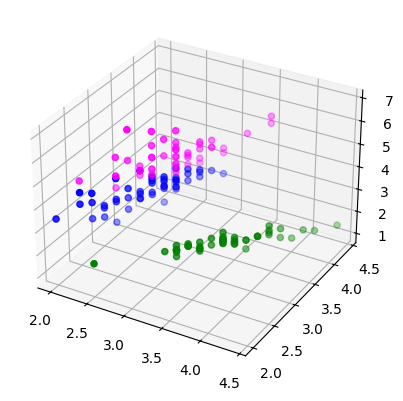

In [4]:
# We have 4 dimensions of data, plot the first three colums in 3D
X=iris.data
y=iris.target
import matplotlib.pyplot as plt
axes1=plt.axes(projection='3d')
axes1.scatter3D(X[y==0,1],X[y==0,1],X[y==0,2],color='green')
axes1.scatter3D(X[y==1,1],X[y==1,1],X[y==1,2],color='blue')
axes1.scatter3D(X[y==2,1],X[y==2,1],X[y==2,2],color='magenta')
plt.show


[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


<function matplotlib.pyplot.show(close=None, block=None)>

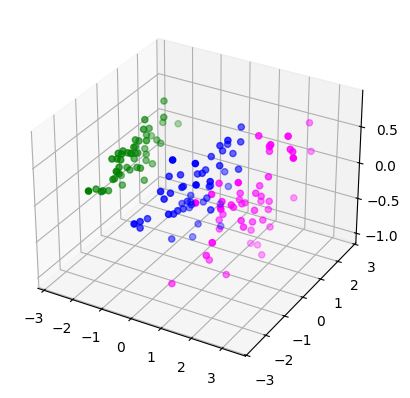

In [5]:
# Pre-processing is an important step, you can try either StandardScaler (zero mean, unit variance of features)
# or MinMaxScaler (to interval from 0 to 1)
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
Xscaler = StandardScaler()
Xpp=Xscaler.fit_transform(X)

# define PCA object (three components), fit and transform the data
pca = PCA(n_components=3)
pca.fit(Xpp)
Xpca = pca.transform(Xpp)
print(pca.get_covariance())
# you can plot the transformed feature space in 3D:
axes2=plt.axes(projection='3d')
axes2.scatter3D(Xpca[y==0,0],Xpca[y==0,1],Xpca[y==0,2],color='green')
axes2.scatter3D(Xpca[y==1,0],Xpca[y==1,1],Xpca[y==1,2],color='blue')
axes2.scatter3D(Xpca[y==2,0],Xpca[y==2,1],Xpca[y==2,2],color='magenta')
plt.show


In [6]:
# Compute pca.explained_variance_ and pca.explained_cariance_ratio_values
pca.explained_variance_

array([2.93808505, 0.9201649 , 0.14774182])

In [7]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922])

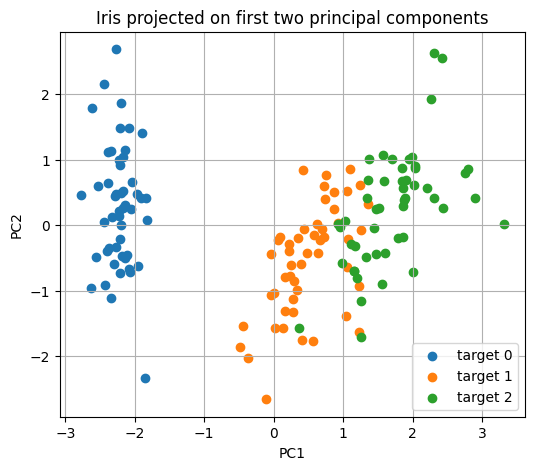

In [8]:
# Plot the principal components in 2D, mark different targets in color
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

# PC1 = Xpca[:,0], PC2 = Xpca[:,1]
plt.scatter(Xpca[y==0, 0], Xpca[y==0, 1], label="target 0")
plt.scatter(Xpca[y==1, 0], Xpca[y==1, 1], label="target 1")
plt.scatter(Xpca[y==2, 0], Xpca[y==2, 1], label="target 2")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Iris projected on first two principal components")
plt.legend()
plt.grid(True)
plt.show()

# KNN classifier

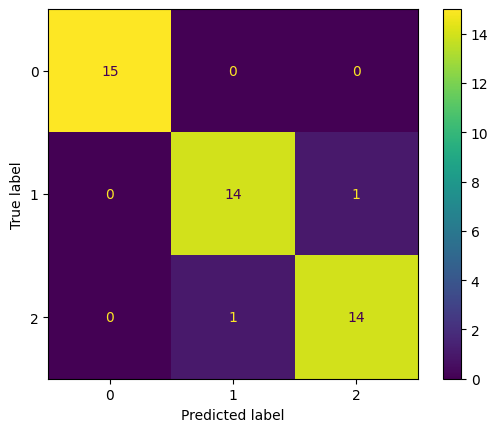

In [9]:
# Import train_test_split as in last PC lab, split X (original) into train and test, train KNN classifier on full 4-dimensional X


from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)

knn1=KNeighborsClassifier(n_neighbors = 3)
knn1.fit(X_train, y_train)

Ypred=knn1.predict(X_test)

# Import and show confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

confusion_matrix(y_test, Ypred)
ConfusionMatrixDisplay.from_predictions(y_test, Ypred)



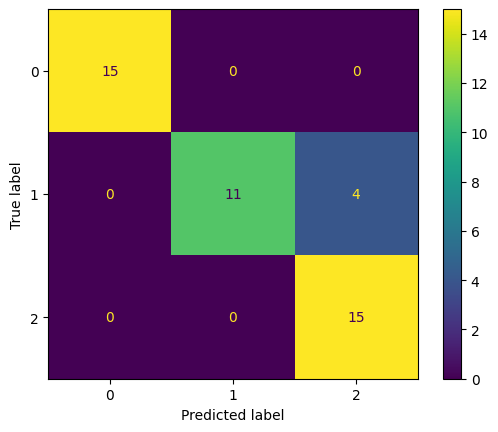

In [10]:
# Now do the same (data set split, KNN, confusion matrix), but for PCA-transformed data (1st two principal components, i.e., first two columns).
# Compare the results with full dataset
X_pca2 = Xpca[:, :2]

X_train, X_test, y_train, y_test = train_test_split(
    X_pca2, y, test_size=0.3, stratify=y
)

knn_pca = KNeighborsClassifier(n_neighbors=3)
knn_pca.fit(X_train, y_train)

Ypred = knn_pca.predict(X_test)

confusion_matrix(y_test, Ypred)
ConfusionMatrixDisplay.from_predictions(y_test, Ypred)

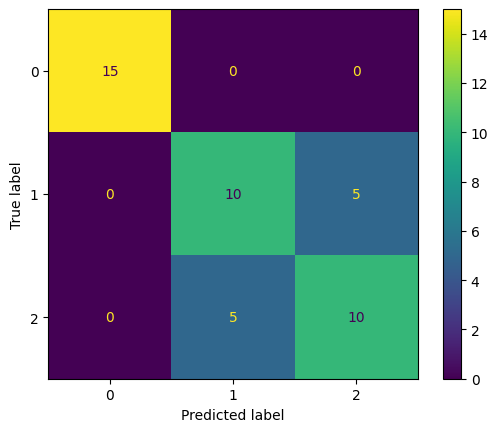

In [13]:
# Now do the same, but use only 2-dimensional data of original X (first two columns)
X2 = X[:, :2]

X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.3, stratify=y
)

knn2 = KNeighborsClassifier(n_neighbors=3)
knn2.fit(X_train, y_train)

Ypred = knn2.predict(X_test)

confusion_matrix(y_test, Ypred)
ConfusionMatrixDisplay.from_predictions(y_test, Ypred)